In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

adata = sc.read_h5ad("../data/processed/Filbin_step4.h5ad")
S5 = "~/Downloads/aao4750_filbin_sm_tables5.xlsx"   # <-- adjust path

In [2]:
rng = np.random.default_rng(42)

In [6]:



# --- Step 4  round-trip (must all pass before Step 5 proceeds) ---
print("shape:", adata.shape, "| expect (2456, 8494)")
print("layers:", sorted(adata.layers.keys()), "| expect ['centered_global', 'tpm']")
print("obsp:", sorted(adata.obsp.keys()), "| expect correlation_centered_global, distance_centered_global")
print("obsm:", sorted(adata.obsm.keys()), "| expect X_tsne_corr_postremoval")
print("uns step4 keys:", sorted(adata.uns["step4"].keys()) if "step4" in adata.uns else "MISSING")
print()

# Per-patient counts (anchor: MUV5 706, BCH836 527, BCH869 492, BCH1126 299, MUV10 284, MUV1 146)
print("per-patient counts:")
print(adata.obs["patient"].value_counts())
print("sum:", adata.obs["patient"].value_counts().sum(), "| expect 2456")
print()

# X identity + centered sanity (anchors from §7)
X = adata.X if isinstance(adata.X, np.ndarray) else adata.X.toarray()
print(f".X mean: {X.mean():.4f} (expect ~1.428 on 2458; slight drift on 2456 OK)")
print(f".X zero fraction: {(X==0).mean():.4f} (expect ~0.544)")
print(f".X range: [{X.min():.2f}, {X.max():.2f}] (expect [0, ~15.15])")

cen = adata.layers["centered_global"]
cen = cen if isinstance(cen, np.ndarray) else cen.toarray()
print(f"centered std: {cen.std():.4f} (expect ~1.6411)")

# obsp shape + t-SNE coord ranges
C = adata.obsp["correlation_centered_global"]
print(f"correlation_centered_global shape: {C.shape} (expect (2456, 2456))")
tsne = adata.obsm["X_tsne_corr_postremoval"]
print(f"t-SNE X range: [{tsne[:,0].min():.1f}, {tsne[:,0].max():.1f}] (expect ~[-37.7, 34.4])")
print(f"t-SNE Y range: [{tsne[:,1].min():.1f}, {tsne[:,1].max():.1f}] (expect ~[-40.4, 37.3])")

shape: (2456, 8494) | expect (2456, 8494)
layers: ['centered_global', 'centered_within_tumor', 'tpm'] | expect ['centered_global', 'tpm']
obsp: ['correlation_centered_global', 'distance_centered_global'] | expect correlation_centered_global, distance_centered_global
obsm: ['X_tsne_corr_postremoval'] | expect X_tsne_corr_postremoval
uns step4 keys: ['centered_layer_used', 'correlation_key', 'distance', 'distance_key', 'inspect_but_keep_cells', 'leaves_global', 'leaves_per_patient', 'linkage_method', 'n_cells_final', 'n_cells_input', 'patient_order', 'removed_artifact_cells', 'tsne_key', 'tsne_params']

per-patient counts:
MUV5       706
BCH836     527
BCH869     492
BCH1126    299
MUV10      286
MUV1       146
Name: patient, dtype: int64
sum: 2456 | expect 2456

.X mean: 1.4280 (expect ~1.428 on 2458; slight drift on 2456 OK)
.X zero fraction: 0.5440 (expect ~0.544)
.X range: [0.00, 15.15] (expect [0, ~15.15])
centered std: 1.6891 (expect ~1.6411)
correlation_centered_global shape: (245

In [7]:
genes_in_matrix = set(adata.var_names)

# ---- Filbin Table S5 malignant programs (Filbin-native) ----


df = pd.read_excel(S5, sheet_name="Sheet1", header=None)
hdr = df.iloc[2].tolist()
body = df.iloc[3:].reset_index(drop=True); body.columns = hdr
def col(c):
    v = body[c].dropna().astype(str).str.strip()
    return [g for g in v if g and g != "nan"]

programs = {
    "Cellcycle":    col("Cellcycle"),
    "OC":           col("OC"),
    "AC":           col("AC"),
    "OPC_shared":   col("OPC-shared"),
    "OPC_variable": col("OPC-variable"),
}
programs["P4_OPC_merged"] = list(dict.fromkeys(programs["OPC_shared"] + programs["OPC_variable"]))

# ---- Filbin fig. S3B NM signatures (figure row labels, not in any spreadsheet) ----
nm = {
    "NM_oligodendrocyte": ["PLP1", "MOG", "MOBP", "MBP", "CLDN11"],
    "NM_immune": ["TYROBP", "PTPRC", "HLA-DRA", "P2RY12", "FCGR2A",
                  "CSF1R", "CD74", "CD68", "CD53", "AIF1"],
}

all_sigs = {**programs, **nm}

print(f"{'signature':<22} {'total':>5} {'found':>5} {'frac':>6}   missing")
print("-" * 80)
for name, glist in all_sigs.items():
    found = [g for g in glist if g in genes_in_matrix]
    missing = [g for g in glist if g not in genes_in_matrix]
    frac = len(found) / len(glist)
    miss_str = ", ".join(missing) if missing else "—"
    print(f"{name:<22} {len(glist):>5} {len(found):>5} {frac:>6.2f}   {miss_str}")

# stash the *filtered* lists (only genes present) for scoring
sigs_present = {name: [g for g in glist if g in genes_in_matrix]
                for name, glist in all_sigs.items()}

signature              total found   frac   missing
--------------------------------------------------------------------------------
Cellcycle                 50    50   1.00   —
OC                        50    50   1.00   —
AC                        50    50   1.00   —
OPC_shared                19    19   1.00   —
OPC_variable              50    50   1.00   —
P4_OPC_merged             68    68   1.00   —
NM_oligodendrocyte         5     5   1.00   —
NM_immune                 10    10   1.00   —


/home/kian/anaconda3/envs/dmg-py/lib/python3.11/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


In [10]:
# How does expression-bin construction behave on each substrate?
# Control-gene bins should be based on average expression E, not centered expression Er.
# Er has per-gene mean ~0 by construction, so ranking Er means would mostly rank numerical noise.

X = adata.X if isinstance(adata.X, np.ndarray) else adata.X.toarray()
Er = adata.layers["centered_global"]
Er = Er if isinstance(Er, np.ndarray) else Er.toarray()

for name, M in [("X (E)", X), ("centered_global (Er)", Er)]:
    gene_means = M.mean(axis=0)  # per-gene average used for expression-level binning

    print(f"--- {name} ---")
    print(f"  gene-mean range: [{gene_means.min():.4f}, {gene_means.max():.4f}]")
    print(f"  gene-mean std:   {gene_means.std():.4f}")

    # Simulate rank-based 25-bin construction.
    # Balanced occupancy alone is not enough: the underlying quantity must be meaningful.
    bins = pd.cut(pd.Series(gene_means).rank(method="min"), 25, labels=False)
    occupancy = bins.value_counts().sort_index()

    print(f"  25-bin occupancy: min={occupancy.min()}, max={occupancy.max()} genes per bin")
    print("  Interpretation:")
    print("    X/E bins are meaningful because genes have different average expression.")
    print("    Er bins are not meaningful because gene means are ~0 after global centering.")
    print()

--- X (E) ---
  gene-mean range: [0.0128, 12.4571]
  gene-mean std:   1.1440
  25-bin occupancy: min=339, max=340 genes per bin
  Interpretation:
    X/E bins are meaningful because genes have different average expression.
    Er bins are not meaningful because gene means are ~0 after global centering.

--- centered_global (Er) ---
  gene-mean range: [-0.0000, 0.0000]
  gene-mean std:   0.0000
  25-bin occupancy: min=338, max=341 genes per bin
  Interpretation:
    X/E bins are meaningful because genes have different average expression.
    Er bins are not meaningful because gene means are ~0 after global centering.



In [11]:
# ---------------------------------------------------------------
# 0. Rebuild gene lists
# ---------------------------------------------------------------

import warnings
from scipy.stats import spearmanr

genes_in_matrix = set(adata.var_names)

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message="Unknown extension is not supported and will be removed",
        category=UserWarning,
        module="openpyxl"
    )
    df = pd.read_excel(S5, sheet_name="Sheet1", header=None)

hdr = df.iloc[2].tolist()
body = df.iloc[3:].reset_index(drop=True)
body.columns = hdr

def col(c):
    v = body[c].dropna().astype(str).str.strip()
    return [g for g in v if g and g != "nan"]

programs = {
    "Cellcycle":    col("Cellcycle"),
    "OC":           col("OC"),
    "AC":           col("AC"),
    "OPC_shared":   col("OPC-shared"),
    "OPC_variable": col("OPC-variable"),
}

programs["P4_OPC_merged"] = list(
    dict.fromkeys(programs["OPC_shared"] + programs["OPC_variable"])
)

nm = {
    "NM_oligodendrocyte": ["PLP1", "MOG", "MOBP", "MBP", "CLDN11"],
    "NM_immune": ["TYROBP", "PTPRC", "HLA-DRA", "P2RY12", "FCGR2A",
                  "CSF1R", "CD74", "CD68", "CD53", "AIF1"],
}

all_sigs = {**programs, **nm}

# Keep only genes present in the current matrix
sigs_present = {
    name: [g for g in glist if g in genes_in_matrix]
    for name, glist in all_sigs.items()
}

print(f"{'signature':<22} {'total':>5} {'found':>5} {'frac':>6}   missing")
print("-" * 80)

for name, glist in all_sigs.items():
    found = sigs_present[name]
    missing = [g for g in glist if g not in genes_in_matrix]
    frac = len(found) / len(glist) if len(glist) > 0 else np.nan
    miss_str = ", ".join(missing) if missing else "—"

    print(f"{name:<22} {len(glist):>5} {len(found):>5} {frac:>6.2f}   {miss_str}")


# ---------------------------------------------------------------
# 1. Substrates and Ea
# ---------------------------------------------------------------

X = adata.X if isinstance(adata.X, np.ndarray) else adata.X.toarray()

Er = adata.layers["centered_global"]
Er = Er if isinstance(Er, np.ndarray) else Er.toarray()

tpm = adata.layers["tpm"]
tpm = tpm if isinstance(tpm, np.ndarray) else tpm.toarray()

# Aggregate expression used only for expression-matched control bins
Ea = np.log2(tpm.mean(axis=0) + 1.0)


# ---------------------------------------------------------------
# 2. Build 25 Ea bins
# ---------------------------------------------------------------

gene_names = np.asarray(adata.var_names)
name_to_idx = {g: i for i, g in enumerate(gene_names)}

bin_id = pd.qcut(Ea, 25, labels=False, duplicates="drop")
bin_id = np.asarray(bin_id)

bin_to_genes = {
    b: np.where(bin_id == b)[0]
    for b in np.unique(bin_id)
}

occ = pd.Series(bin_id).value_counts().sort_index()

print(f"\nbins: {bin_id.max() + 1} | occupancy min={occ.min()} max={occ.max()}")


# ---------------------------------------------------------------
# 3. Filbin-style scorer
#    Binning/control genes are based on Ea.
#    Scores are computed on chosen substrate M.
# ---------------------------------------------------------------

def filbin_score(M, sig_genes, ctrl_size=100, seed=42):
    r = np.random.default_rng(seed)

    sig_idx = np.array(
        [name_to_idx[g] for g in sig_genes if g in name_to_idx],
        dtype=int
    )

    if len(sig_idx) == 0:
        raise ValueError("No signature genes found in matrix.")

    ctrl_idx = []

    sig_set = set(sig_idx)

    for gi in sig_idx:
        pool = bin_to_genes[bin_id[gi]]

        # avoid using signature genes as matched controls
        pool = np.array([p for p in pool if p not in sig_set], dtype=int)

        if len(pool) == 0:
            raise ValueError(f"No control genes left for gene index {gi}")

        sampled = r.choice(
            pool,
            size=min(ctrl_size, len(pool)),
            replace=len(pool) < ctrl_size,
        )

        ctrl_idx.extend(sampled.tolist())

    ctrl_idx = np.array(ctrl_idx, dtype=int)

    sig_mean = M[:, sig_idx].mean(axis=1)
    ctrl_mean = M[:, ctrl_idx].mean(axis=1)

    return np.asarray(sig_mean - ctrl_mean).ravel()


# ---------------------------------------------------------------
# 4. Run 3 methods per signature
# ---------------------------------------------------------------

results = pd.DataFrame(index=adata.obs_names)

for name, glist in sigs_present.items():
    results[f"{name}__custom_Er"] = filbin_score(Er, glist)
    results[f"{name}__custom_X"]  = filbin_score(X, glist)

    sc.tl.score_genes(
        adata,
        gene_list=glist,
        score_name="_tmp",
        ctrl_size=100,
        n_bins=25,
        use_raw=False,
        random_state=42,
    )

    results[f"{name}__scanpy_X"] = adata.obs["_tmp"].to_numpy()

adata.obs.drop(columns=["_tmp"], inplace=True, errors="ignore")


# ---------------------------------------------------------------
# 5. Store Filbin-anchor scores onto adata.obs
# ---------------------------------------------------------------

for name in sigs_present:
    adata.obs[f"score_{name}"] = results[f"{name}__custom_Er"].to_numpy()


# ---------------------------------------------------------------
# 6. Store signature metadata
# ---------------------------------------------------------------

adata.uns["step5_signatures"] = {
    "all_sigs": all_sigs,
    "sigs_present": sigs_present,
    "binning_basis": "Ea = log2(mean(TPM) + 1)",
    "score_basis": "centered_global",
    "control_genes_per_signature_gene": 100,
    "random_seed": 42,
}


# ---------------------------------------------------------------
# 7. Comparison table
# ---------------------------------------------------------------

print(f"\n{'signature':<20}{'cEr~cX':>9}{'cX~spX':>9}{'cEr~spX':>9}")

for name in sigs_present:
    a = results[f"{name}__custom_Er"]
    b = results[f"{name}__custom_X"]
    c = results[f"{name}__scanpy_X"]

    print(
        f"{name:<20}"
        f"{spearmanr(a, b).correlation:>9.4f}"
        f"{spearmanr(b, c).correlation:>9.4f}"
        f"{spearmanr(a, c).correlation:>9.4f}"
    )

signature              total found   frac   missing
--------------------------------------------------------------------------------
Cellcycle                 50    50   1.00   —
OC                        50    50   1.00   —
AC                        50    50   1.00   —
OPC_shared                19    19   1.00   —
OPC_variable              50    50   1.00   —
P4_OPC_merged             68    68   1.00   —
NM_oligodendrocyte         5     5   1.00   —
NM_immune                 10    10   1.00   —

bins: 25 | occupancy min=339 max=340

signature              cEr~cX   cX~spX  cEr~spX
Cellcycle              1.0000   0.9774   0.9774
OC                     1.0000   0.9625   0.9625
AC                     1.0000   0.9641   0.9641
OPC_shared             1.0000   0.9897   0.9897
OPC_variable           1.0000   0.9755   0.9755
P4_OPC_merged          1.0000   0.9676   0.9676
NM_oligodendrocyte     1.0000   0.9517   0.9517
NM_immune              1.0000   0.7816   0.7816


>The Filbin-style signature scores were computed using expression-matched control genes. Control genes were selected from 25 bins defined by aggregate expression (`Ea = log2(mean(TPM) + 1)`), while the final scores were computed on globally centered expression values (`centered_global`). All genes from the malignant and non-malignant marker signatures were present in the filtered matrix. Custom scores computed on `centered_global` and on `X` had identical rank ordering, while Scanpy’s `score_genes` scores were highly correlated but not identical, especially for the small immune signature. For downstream analysis, I use the custom `centered_global` scores as the Filbin-style anchor scores.

In [13]:
# 5.x — compare stored Step 3 Ea with Ea recomputed after Step 4 artifact removal
# stored adata.var["Ea"] was computed before artifact removal, on 2458 cells.
# current Ea was recomputed after removing the curated MUV5 artifact pair, on 2456 cells.

stored = adata.var["Ea"].to_numpy()
diff = np.abs(Ea - stored)

# 1. How many genes differ, and by how much?
print(f"genes with |diff| > 1e-4: {(diff > 1e-4).sum()} / {len(diff)}")
print(
    f"diff distribution: "
    f"median={np.median(diff):.2e}, "
    f"99th pct={np.percentile(diff, 99):.2e}, "
    f"max={diff.max():.2e}"
)

# 2. Show top 10 genes with largest differences
top = np.argsort(diff)[::-1][:10]

print("\ntop 10 differing genes:")
for i in top:
    print(
        f"  {adata.var_names[i]:<12} "
        f"stored={stored[i]:.4f}  "
        f"recomputed={Ea[i]:.4f}  "
        f"diff={diff[i]:.4f}"
    )

# 3. Systematic direction of change
signed = Ea - stored

print(
    f"\nsigned diff: mean={signed.mean():.2e} "
    f"(positive = recomputed Ea higher; negative = recomputed Ea lower)"
)

# 4. Current cell count
print(f"\ncurrent n_cells: {adata.n_obs}  (stored Ea was computed on 2458 cells at Step 3)")

# 5. Inspect the top offender by tumor
g = adata.var_names[top[0]]
gi = list(adata.var_names).index(g)

tpm = adata.layers["tpm"]
tpm = tpm if isinstance(tpm, np.ndarray) else tpm.toarray()

print(f"\noffender '{g}' mean TPM by tumor:")

patients_for_print = (
    adata.obs["patient"].cat.categories
    if hasattr(adata.obs["patient"], "cat")
    else adata.obs["patient"].unique()
)

for pt in patients_for_print:
    mask = (adata.obs["patient"] == pt).to_numpy()
    print(f"  {pt:<10} {tpm[mask, gi].mean():.2f}")

genes with |diff| > 1e-4: 8180 / 8494
diff distribution: median=1.12e-03, 99th pct=8.45e-03, max=5.41e-02

top 10 differing genes:
  IFITM1       stored=4.8808  recomputed=4.8267  diff=0.0541
  IFITM3       stored=6.6602  recomputed=6.6233  diff=0.0370
  SLC25A1      stored=6.2577  recomputed=6.2293  diff=0.0284
  PFKFB2       stored=5.2699  recomputed=5.2420  diff=0.0279
  RASL12       stored=4.1253  recomputed=4.0983  diff=0.0269
  TRIM47       stored=4.3173  recomputed=4.2926  diff=0.0247
  APOE         stored=8.1087  recomputed=8.0857  diff=0.0230
  GPT2         stored=4.4470  recomputed=4.4264  diff=0.0206
  GUCY1A3      stored=4.4398  recomputed=4.4193  diff=0.0205
  NUDT4P1      stored=4.8847  recomputed=4.8644  diff=0.0202

signed diff: mean=3.17e-05 (positive = recomputed Ea higher; negative = recomputed Ea lower)

current n_cells: 2456  (stored Ea was computed on 2458 cells at Step 3)

offender 'IFITM1' mean TPM by tumor:
  BCH836     0.47
  BCH869     0.68
  BCH1126    49.82

In [14]:
# 5.x — check whether the TPM layer, .X, and Ea are internally consistent
# Current object has 2456 cells after curated artifact removal.

tpm = adata.layers["tpm"]
tpm = tpm if isinstance(tpm, np.ndarray) else tpm.toarray()

# A. Does tpm still sum to 1e6 per cell, or was it filtered without renormalization?
cell_sums = tpm.sum(axis=1)

print(
    f"per-cell TPM sum: "
    f"median={np.median(cell_sums):.1f}, "
    f"min={cell_sums.min():.1f}, "
    f"max={cell_sums.max():.1f}"
)

print(
    "   (1e6 = original full-transcriptome TPM; "
    "smaller/variable = gene-filtered TPM not renormalized; "
    "1e6 again = renormalized after filtering)"
)


# B. Reconstruct TPM from .X
# .X = E = log2(TPM / 10 + 1)
# Therefore: TPM = (2**E - 1) * 10

X = adata.X
X = X if isinstance(X, np.ndarray) else X.toarray()

tpm_from_X = (np.power(2.0, X) - 1.0) * 10.0

Ea_from_X = np.log2(tpm_from_X.mean(axis=0) + 1.0)

stored_Ea = adata.var["Ea"].to_numpy()   # Step 3/pre-removal Ea
current_Ea_from_tpm_layer = np.log2(tpm.mean(axis=0) + 1.0)


# C. Compare Ea sources

d_fromX_vs_stored = np.abs(Ea_from_X - stored_Ea)
d_tpmLayer_vs_stored = np.abs(current_Ea_from_tpm_layer - stored_Ea)
d_fromX_vs_tpmLayer = np.abs(Ea_from_X - current_Ea_from_tpm_layer)

print(
    f"\nEa from .X-inverted TPM vs stored Step 3 Ea: "
    f"max diff = {d_fromX_vs_stored.max():.2e}, "
    f"median = {np.median(d_fromX_vs_stored):.2e}"
)

print(
    f"Ea from tpm layer vs stored Step 3 Ea:       "
    f"max diff = {d_tpmLayer_vs_stored.max():.2e}, "
    f"median = {np.median(d_tpmLayer_vs_stored):.2e}"
)

print(
    f"Ea from .X-inverted TPM vs tpm layer:        "
    f"max diff = {d_fromX_vs_tpmLayer.max():.2e}, "
    f"median = {np.median(d_fromX_vs_tpmLayer):.2e}"
)


# D. Compare TPM layer to TPM reconstructed from .X

d_tpm = np.abs(tpm - tpm_from_X)

print(
    f"\ntpm layer vs (2^X - 1) * 10: "
    f"max abs diff = {d_tpm.max():.4f}, "
    f"mean = {d_tpm.mean():.6f}"
)


# E. Example gene check

gene_to_check = "BUB1B"

if gene_to_check in adata.var_names:
    gi = list(adata.var_names).index(gene_to_check)

    print(f"\n{gene_to_check} mean:")
    print(
        f"  tpm_layer  = {tpm[:, gi].mean():.4f}  "
        f"-> Ea = {np.log2(tpm[:, gi].mean() + 1):.4f}"
    )
    print(
        f"  X_inverted = {tpm_from_X[:, gi].mean():.4f}  "
        f"-> Ea = {np.log2(tpm_from_X[:, gi].mean() + 1):.4f}"
    )
    print(f"  stored Ea  = {stored_Ea[gi]:.4f}")
else:
    print(f"\n{gene_to_check} not found in adata.var_names")

per-cell TPM sum: median=951915.5, min=827230.2, max=988987.2
   (1e6 = original full-transcriptome TPM; smaller/variable = gene-filtered TPM not renormalized; 1e6 again = renormalized after filtering)

Ea from .X-inverted TPM vs stored Step 3 Ea: max diff = 5.41e-02, median = 1.12e-03
Ea from tpm layer vs stored Step 3 Ea:       max diff = 5.41e-02, median = 1.12e-03
Ea from .X-inverted TPM vs tpm layer:        max diff = 9.54e-07, median = 0.00e+00

tpm layer vs (2^X - 1) * 10: max abs diff = 0.0781, mean = 0.000012

BUB1B mean:
  tpm_layer  = 20.4851  -> Ea = 4.4253
  X_inverted = 20.4851  -> Ea = 4.4253
  stored Ea  = 4.4241


In [15]:
# ---------------------------------------------------------------
# 5.x — choose final score columns for downstream use
# ---------------------------------------------------------------
# Malignant/state programs:
#   keep Filbin-style scores computed on centered_global (custom_Er)
#
# Non-malignant identity signatures:
#   use absolute expression substrate (custom_X), because these marker sets
#   are intended to detect marker-positive immune/oligodendrocyte cells.

# Store NM identity scores from absolute expression
for nm_name in ["NM_oligodendrocyte", "NM_immune"]:
    adata.obs[f"score_{nm_name}"] = results[f"{nm_name}__custom_X"].to_numpy()

# Record score substrate choice
adata.uns["step5_score_substrates"] = {
    "malignant_program_scores": "custom_Er / centered_global",
    "nonmalignant_identity_scores": "custom_X / absolute E",
    "NM_scores_overwritten_with_custom_X": [
        "score_NM_oligodendrocyte",
        "score_NM_immune",
    ],
}

# Confirm what's now stored
score_cols = [c for c in adata.obs.columns if c.startswith("score_")]

print("stored score columns:")
for c in score_cols:
    print(f"  {c}")

print()
print(
    adata.obs[score_cols]
    .describe()
    .T[["mean", "std", "min", "max"]]
    .round(3)
)

stored score columns:
  score_Cellcycle
  score_OC
  score_AC
  score_OPC_shared
  score_OPC_variable
  score_P4_OPC_merged
  score_NM_oligodendrocyte
  score_NM_immune

                           mean    std    min    max
score_Cellcycle           0.000  1.145 -1.330  4.974
score_OC                 -0.000  0.794 -1.346  4.515
score_AC                  0.000  1.439 -1.737  5.266
score_OPC_shared          0.000  1.144 -3.408  2.831
score_OPC_variable       -0.000  1.138 -2.448  4.102
score_P4_OPC_merged       0.000  0.903 -2.437  3.025
score_NM_oligodendrocyte -1.808  1.853 -3.859  7.355
score_NM_immune          -1.401  1.336 -2.425  6.333


In [16]:
# 5.x — inspect high-scoring tails for non-malignant marker signatures

for nm_name, thresh in [
    ("score_NM_oligodendrocyte", 2.0),
    ("score_NM_immune", 2.0),
]:
    s = adata.obs[nm_name]
    hi = adata.obs.index[s > thresh]

    print(f"\n{nm_name} > {thresh}: {len(hi)} cells")
    print(f"  by tumor: {adata.obs.loc[hi, 'patient'].value_counts().to_dict()}")

    print("  top cells:")
    top = s.sort_values(ascending=False).head(8)

    for cell, val in top.items():
        print(
            f"    {cell:<22} "
            f"{nm_name}={val:>6.2f}  "
            f"oligo={adata.obs.loc[cell, 'score_NM_oligodendrocyte']:>6.2f}  "
            f"immune={adata.obs.loc[cell, 'score_NM_immune']:>6.2f}  "
            f"({adata.obs.loc[cell, 'patient']})"
        )


# Cross-check: do oligo-high and immune-high overlap?
oligo_hi = set(
    adata.obs.index[adata.obs["score_NM_oligodendrocyte"] > 2.0]
)

immune_hi = set(
    adata.obs.index[adata.obs["score_NM_immune"] > 2.0]
)

print(
    f"\noligo-high: {len(oligo_hi)}, "
    f"immune-high: {len(immune_hi)}, "
    f"overlap: {len(oligo_hi & immune_hi)}"
)


score_NM_oligodendrocyte > 2.0: 119 cells
  by tumor: {'MUV5': 59, 'BCH836': 34, 'BCH1126': 19, 'MUV1': 5, 'BCH869': 2, 'MUV10': 0}
  top cells:
    MUV5-P05-A02           score_NM_oligodendrocyte=  7.36  oligo=  7.36  immune= -1.17  (MUV5)
    MUV5-P03-C04           score_NM_oligodendrocyte=  7.23  oligo=  7.23  immune= -0.81  (MUV5)
    MUV5-P02-G12           score_NM_oligodendrocyte=  6.89  oligo=  6.89  immune= -1.03  (MUV5)
    MUV5-P04-H04           score_NM_oligodendrocyte=  6.83  oligo=  6.83  immune= -1.35  (MUV5)
    MUV5-P05-F08           score_NM_oligodendrocyte=  6.81  oligo=  6.81  immune= -1.54  (MUV5)
    MUV5-P04-D03           score_NM_oligodendrocyte=  6.71  oligo=  6.71  immune= -1.41  (MUV5)
    MUV5-P06-G03           score_NM_oligodendrocyte=  6.68  oligo=  6.68  immune= -1.09  (MUV5)
    MUV5-P03-F12           score_NM_oligodendrocyte=  6.56  oligo=  6.56  immune= -1.37  (MUV5)

score_NM_immune > 2.0: 85 cells
  by tumor: {'BCH836': 52, 'BCH1126': 32, 'BCH869': 1

In [17]:
# 5.x — check whether NM-marker-high cells also score for malignant programs
# Goal:
#   NM oligodendrocyte-high cells could be true normal oligodendrocytes,
#   but some may be malignant OC-like cancer cells, especially in MUV5.
#   Immune-high cells should generally not score strongly for malignant programs.

oligo_hi = adata.obs["score_NM_oligodendrocyte"] > 2.0
immune_hi = adata.obs["score_NM_immune"] > 2.0

print("OLIGO-HIGH cells — do they co-score on malignant/state programs?")
print(
    adata.obs.loc[
        oligo_hi,
        [
            "score_NM_oligodendrocyte",
            "score_NM_immune",
            "score_OC",
            "score_AC",
            "score_OPC_shared",
            "score_Cellcycle",
        ],
    ]
    .describe()
    .T[["mean", "std", "min", "max"]]
    .round(2)
)

# Split MUV5 oligo-high specifically versus other tumors' oligo-high
muv5_oh = oligo_hi & (adata.obs["patient"] == "MUV5")
other_oh = oligo_hi & (adata.obs["patient"] != "MUV5")

print(f"\nMUV5 oligo-high cells: n = {muv5_oh.sum()}")
print(
    adata.obs.loc[
        muv5_oh,
        ["score_NM_oligodendrocyte", "score_OC", "score_AC", "score_OPC_shared", "score_Cellcycle"],
    ]
    .mean()
    .round(2)
    .to_dict()
)

print(f"\nnon-MUV5 oligo-high cells: n = {other_oh.sum()}")
print(
    adata.obs.loc[
        other_oh,
        ["score_NM_oligodendrocyte", "score_OC", "score_AC", "score_OPC_shared", "score_Cellcycle"],
    ]
    .mean()
    .round(2)
    .to_dict()
)

# Optional working split: among oligo-high cells, who is also OC-program-high?
# Threshold is exploratory. Do not use as final malignancy call.
OC_HIGH_THRESH = 1.0

oligo_hi_oc_hi = oligo_hi & (adata.obs["score_OC"] > OC_HIGH_THRESH)
oligo_hi_oc_low = oligo_hi & (adata.obs["score_OC"] <= OC_HIGH_THRESH)

print(f"\noligo-high AND OC-high (score_OC > {OC_HIGH_THRESH}): {oligo_hi_oc_hi.sum()} cells")
print(f"  by tumor: {adata.obs.loc[oligo_hi_oc_hi, 'patient'].value_counts().to_dict()}")

print(f"\noligo-high but OC-low (score_OC <= {OC_HIGH_THRESH}): {oligo_hi_oc_low.sum()} cells")
print(f"  by tumor: {adata.obs.loc[oligo_hi_oc_low, 'patient'].value_counts().to_dict()}")

# Immune-high: should not co-score strongly on malignant programs if truly immune
print(
    f"\nIMMUNE-HIGH cells (n={immune_hi.sum()}) — mean malignant/state-program scores:"
)
print(
    adata.obs.loc[
        immune_hi,
        ["score_OC", "score_AC", "score_OPC_shared", "score_Cellcycle"],
    ]
    .mean()
    .round(2)
    .to_dict()
)

OLIGO-HIGH cells — do they co-score on malignant/state programs?
                          mean   std   min   max
score_NM_oligodendrocyte  5.40  1.17  2.06  7.36
score_NM_immune          -1.57  0.27 -2.11 -0.57
score_OC                  2.46  0.66  0.94  4.52
score_AC                 -0.47  0.35 -1.36  0.47
score_OPC_shared         -2.06  0.73 -3.18  0.19
score_Cellcycle          -0.45  0.27 -1.06  0.48

MUV5 oligo-high cells: n = 59
{'score_NM_oligodendrocyte': 5.179999828338623, 'score_OC': 2.6700000762939453, 'score_AC': -0.5600000023841858, 'score_OPC_shared': -2.240000009536743, 'score_Cellcycle': -0.38999998569488525}

non-MUV5 oligo-high cells: n = 60
{'score_NM_oligodendrocyte': 5.619999885559082, 'score_OC': 2.25, 'score_AC': -0.3700000047683716, 'score_OPC_shared': -1.8799999952316284, 'score_Cellcycle': -0.5099999904632568}

oligo-high AND OC-high (score_OC > 1.0): 118 cells
  by tumor: {'MUV5': 58, 'BCH836': 34, 'BCH1126': 19, 'MUV1': 5, 'BCH869': 2, 'MUV10': 0}

oligo-hig

In [18]:
# ---------------------------------------------------------------
# Load the raw cohort and inspect possible Oligo labels
# ---------------------------------------------------------------

raw = sc.read_h5ad("../data/processed/Filbin_cohort_raw.h5ad")

print("raw cohort:", raw.shape)
print("\nobs columns:")
print(list(raw.obs.columns))

# Inspect likely annotation columns
candidate_cols = [
    c for c in raw.obs.columns
    if any(key in c.lower() for key in ["group", "cell", "type", "label", "annotation", "source"])
]

print("\nCandidate annotation columns:")
print(candidate_cols)

for c in candidate_cols:
    print(f"\n{c}:")
    print(raw.obs[c].astype(str).value_counts().head(20))

raw cohort: (4058, 23686)

obs columns:
['sample', 'patient', 'source', 'model', 'is_paper_patient', 'in_paper_cohort', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'hk_score', 'hk_score_hounkpe']

Candidate annotation columns:
['source']

source:
patient          3057
model             863
non-malignant     138
Name: source, dtype: int64


In [19]:
# ---------------------------------------------------------------
# Extract the 138 pre-tagged non-malignant / Oligo reference cells
# ---------------------------------------------------------------

oligo_mask = raw.obs["source"].astype(str).eq("non-malignant")

print(f"Pre-tagged non-malignant cells found: {oligo_mask.sum()}")

raw_oligo = raw[oligo_mask].copy()

print("raw_oligo:", raw_oligo.shape)
print("\nsource counts:")
print(raw_oligo.obs["source"].value_counts())

print("\npatient counts:")
print(raw_oligo.obs["patient"].value_counts())

print("\nsample counts:")
print(raw_oligo.obs["sample"].value_counts())

Pre-tagged non-malignant cells found: 138
raw_oligo: (138, 23686)

source counts:
non-malignant    138
Name: source, dtype: int64

patient counts:
Oligo    138
Name: patient, dtype: int64

sample counts:
Oligo    138
Name: sample, dtype: int64


In [22]:
# ---------------------------------------------------------------
# Check marker expression in the 138 pre-tagged Oligo cells
# ---------------------------------------------------------------

oligo_markers = ["PLP1", "MOG", "MOBP", "MBP", "CLDN11"]
immune_markers = ["TYROBP", "PTPRC", "HLA-DRA", "P2RY12", "FCGR2A", "CSF1R", "CD74", "CD68", "CD53", "AIF1"]

markers = oligo_markers + immune_markers
markers_present = [g for g in markers if g in raw_oligo.var_names]
markers_missing = [g for g in markers if g not in raw_oligo.var_names]

print("markers present:", markers_present)
print("markers missing:", markers_missing)

X_ref = raw_oligo.X
X_ref = X_ref if isinstance(X_ref, np.ndarray) else X_ref.toarray()

marker_idx = [list(raw_oligo.var_names).index(g) for g in markers_present]

marker_summary = pd.DataFrame(
    {
        "mean_raw_X": X_ref[:, marker_idx].mean(axis=0),
        "frac_detected": (X_ref[:, marker_idx] > 0).mean(axis=0),
    },
    index=markers_present,
)

print(marker_summary.round(3))

markers present: ['PLP1', 'MOG', 'MOBP', 'MBP', 'CLDN11', 'TYROBP', 'PTPRC', 'HLA-DRA', 'P2RY12', 'FCGR2A', 'CSF1R', 'CD74', 'CD68', 'CD53', 'AIF1']
markers missing: []
         mean_raw_X  frac_detected
PLP1      27769.956          0.986
MOG        1702.458          0.993
MOBP        367.532          0.928
MBP        6466.225          0.986
CLDN11     2137.012          0.986
TYROBP        0.000          0.000
PTPRC         1.367          0.109
HLA-DRA       0.000          0.000
P2RY12        0.018          0.007
FCGR2A        1.594          0.065
CSF1R         0.431          0.014
CD74          4.742          0.022
CD68         17.640          0.630
CD53          0.000          0.000
AIF1          0.000          0.000


In [23]:
# Cross-tab the candidate flags to locate the 138 pre-tagged non-malignant / Oligo cells

print("in_paper_cohort value counts:")
print(raw.obs["in_paper_cohort"].value_counts(dropna=False))

print("\nsource value counts:")
print(raw.obs["source"].value_counts(dropna=False))

print("\nmodel value counts:")
print(raw.obs["model"].value_counts(dropna=False))

print("\npatient value counts:")
print(raw.obs["patient"].value_counts(dropna=False))

print("\nsample value counts:")
print(raw.obs["sample"].value_counts(dropna=False))


# The 138 should be source == non-malignant, patient == Oligo, sample == Oligo
print("\n--- cross-tabs to find the 138 ---")

print("\nsource x in_paper_cohort:")
print(pd.crosstab(raw.obs["source"], raw.obs["in_paper_cohort"], dropna=False))

print("\nsource x patient:")
print(pd.crosstab(raw.obs["source"], raw.obs["patient"], dropna=False))

print("\nsource x sample:")
print(pd.crosstab(raw.obs["source"], raw.obs["sample"], dropna=False))

print("\nis_paper_patient x in_paper_cohort:")
print(pd.crosstab(raw.obs["is_paper_patient"], raw.obs["in_paper_cohort"], dropna=False))


# Direct extraction check
oligo_ref_mask = (
    (raw.obs["source"].astype(str) == "non-malignant") &
    (raw.obs["patient"].astype(str) == "Oligo") &
    (raw.obs["sample"].astype(str) == "Oligo")
)

print(f"\nOligo reference cells by direct mask: {oligo_ref_mask.sum()}")

raw_oligo = raw[oligo_ref_mask].copy()
print("raw_oligo:", raw_oligo.shape)

in_paper_cohort value counts:
True     2458
False    1600
Name: in_paper_cohort, dtype: int64

source value counts:
patient          3057
model             863
non-malignant     138
Name: source, dtype: int64

model value counts:
primary_tumor      3057
GS                  290
PDX                 167
DGC75               165
oligodendrocyte     138
DGC100               89
SF                   84
GF                   68
Name: model, dtype: int64

patient value counts:
BCH869     1355
MUV5        708
BCH836      527
MGH66       442
BCH1126     299
MUV10       286
MUV1        146
Oligo       138
MGH101       92
MGH104       65
Name: patient, dtype: int64

sample value counts:
MUV5             708
BCH836           527
BCH869           492
MGH66            442
BCH1126          299
BCH869_GS        290
MUV10            286
BCH869_PDX       167
BCH869_DGC75     165
MUV1             146
Oligo            138
MGH101            92
BCH869_DGC100     89
BCH869_SF         84
BCH869_GF         68
MGH1

In [24]:
# ---------------------------------------------------------------
# Reference: the 138 known non-malignant oligodendrocytes
# ---------------------------------------------------------------

ref = raw[raw.obs["source"] == "non-malignant"].copy()
print(f"reference non-malignant oligos: {ref.n_obs} cells")

# Subset to OUR 8,494 frozen genes, in the same order as adata
common = [g for g in adata.var_names if g in set(ref.var_names)]
assert len(common) == adata.n_vars, f"gene mismatch: {len(common)} vs {adata.n_vars}"

ref = ref[:, adata.var_names].copy()

# raw reference .X holds TPM, so build E = log2(TPM/10 + 1)
ref_tpm = ref.X
ref_tpm = ref_tpm if isinstance(ref_tpm, np.ndarray) else ref_tpm.toarray()

ref_E = np.log2(ref_tpm / 10.0 + 1.0)

print(f"ref_E range: [{ref_E.min():.3f}, {ref_E.max():.3f}]")


# ---------------------------------------------------------------
# Score reference using SAME Ea bins and SAME control universe
# ---------------------------------------------------------------

def filbin_score_on(M, sig_genes, ctrl_size=100, seed=42):
    r = np.random.default_rng(seed)

    sig_idx = np.array(
        [name_to_idx[g] for g in sig_genes if g in name_to_idx],
        dtype=int
    )

    if len(sig_idx) == 0:
        raise ValueError("No signature genes found in matrix.")

    ctrl_idx = []
    sig_set = set(sig_idx)

    for gi in sig_idx:
        pool = bin_to_genes[bin_id[gi]]

        # avoid using signature genes as controls
        pool = np.array([p for p in pool if p not in sig_set], dtype=int)

        if len(pool) == 0:
            raise ValueError(f"No control genes left for gene index {gi}")

        sampled = r.choice(
            pool,
            size=min(ctrl_size, len(pool)),
            replace=len(pool) < ctrl_size,
        )

        ctrl_idx.extend(sampled.tolist())

    ctrl_idx = np.array(ctrl_idx, dtype=int)

    return np.asarray(
        M[:, sig_idx].mean(axis=1) - M[:, ctrl_idx].mean(axis=1)
    ).ravel()


ref_score_lists = {
    "NM_oligodendrocyte": nm["NM_oligodendrocyte"],
    "NM_immune": nm["NM_immune"],
    "OC": programs["OC"],
    "AC": programs["AC"],
    "OPC_shared": programs["OPC_shared"],
    "Cellcycle": programs["Cellcycle"],
}

ref_scores = {}

for sig_name, glist in ref_score_lists.items():
    ref_scores[sig_name] = filbin_score_on(ref_E, glist)

ref_df = pd.DataFrame(ref_scores, index=ref.obs_names)


# ---------------------------------------------------------------
# Build in-cohort comparison table on the same absolute E substrate
# ---------------------------------------------------------------
# These use results[...__custom_X], so they are comparable to ref_E scores.

cohort_X_scores = pd.DataFrame(index=adata.obs_names)

for sig_name in ref_score_lists:
    if f"{sig_name}__custom_X" in results.columns:
        cohort_X_scores[sig_name] = results[f"{sig_name}__custom_X"].to_numpy()
    else:
        cohort_X_scores[sig_name] = filbin_score_on(X, ref_score_lists[sig_name])


# ---------------------------------------------------------------
# THE COMPARISON: reference normal oligos vs in-cohort suspects
# ---------------------------------------------------------------

oligo_hi = adata.obs["score_NM_oligodendrocyte"] > 2.0
immune_hi = adata.obs["score_NM_immune"] > 2.0

print("\n=== mean signature scores by group, using absolute E substrate ===")

def row(label, df_like, mask=None):
    if mask is None:
        sub = df_like
    else:
        sub = df_like.loc[mask]

    print(
        f"{label:<34} "
        f"NM_oligo={sub['NM_oligodendrocyte'].mean():6.2f}  "
        f"NM_immune={sub['NM_immune'].mean():6.2f}  "
        f"OC={sub['OC'].mean():6.2f}  "
        f"OPC_sh={sub['OPC_shared'].mean():6.2f}  "
        f"CC={sub['Cellcycle'].mean():6.2f}"
    )

row("REFERENCE normal oligos (138)", ref_df)
row("in-cohort oligo-high (119)", cohort_X_scores, oligo_hi)
row("in-cohort immune-high (85)", cohort_X_scores, immune_hi)
row(f"in-cohort bulk (all {adata.n_obs})", cohort_X_scores)

print("\nReference normal oligos score summary:")
print(ref_df.describe().T[["mean", "std", "min", "max"]].round(2))

reference non-malignant oligos: 138 cells
ref_E range: [0.000, 13.747]

=== mean signature scores by group, using absolute E substrate ===
REFERENCE normal oligos (138)      NM_oligo=  5.23  NM_immune= -1.42  OC=  1.48  OPC_sh= -1.02  CC= -0.85
in-cohort oligo-high (119)         NM_oligo=  5.40  NM_immune= -1.57  OC=  1.90  OPC_sh= -2.40  CC= -1.01
in-cohort immune-high (85)         NM_oligo= -2.06  NM_immune=  5.37  OC= -1.18  OPC_sh= -0.86  CC= -0.82
in-cohort bulk (all 2456)          NM_oligo= -1.81  NM_immune= -1.40  OC= -0.55  OPC_sh= -0.34  CC= -0.56

Reference normal oligos score summary:
                    mean   std   min   max
NM_oligodendrocyte  5.23  1.44 -2.94  6.83
NM_immune          -1.42  0.27 -2.15 -0.70
OC                  1.48  0.39 -0.65  2.38
AC                 -1.17  0.32 -1.85  0.50
OPC_shared         -1.02  0.70 -2.84  1.02
Cellcycle          -0.85  0.26 -1.74 -0.20


In [25]:
# ---------------------------------------------------------------
# Persist Step 5 NM analysis into adata.uns for Step 6 (CNV) reuse
# ---------------------------------------------------------------

oligo_hi = adata.obs["score_NM_oligodendrocyte"] > 2.0
immune_hi = adata.obs["score_NM_immune"] > 2.0

adata.uns["step5_nm"] = {
    # 138-cell non-malignant oligodendrocyte reference
    "reference_oligo_cells": np.asarray(ref.obs_names, dtype=object),
    "reference_scores": {
        k: np.asarray(v, dtype=np.float32)
        for k, v in ref_df.items()
    },

    # In-cohort NM candidate pools.
    # These are expression-based candidate flags, not final malignant/NM labels.
    "oligo_high_cells": np.asarray(adata.obs_names[oligo_hi], dtype=object),
    "immune_high_cells": np.asarray(adata.obs_names[immune_hi], dtype=object),
    "nm_threshold": 2.0,

    # Group-level summary stats from the absolute E-substrate comparison
    "group_summary_absolute_E": {
        "reference_oligo": {
            "n": int(ref.n_obs),
            "NM_oligo": float(ref_df["NM_oligodendrocyte"].mean()),
            "NM_immune": float(ref_df["NM_immune"].mean()),
            "OC": float(ref_df["OC"].mean()),
            "OPC_shared": float(ref_df["OPC_shared"].mean()),
            "Cellcycle": float(ref_df["Cellcycle"].mean()),
        },
        "cohort_oligo_high": {
            "n": int(oligo_hi.sum()),
            "NM_oligo": float(cohort_X_scores.loc[oligo_hi, "NM_oligodendrocyte"].mean()),
            "NM_immune": float(cohort_X_scores.loc[oligo_hi, "NM_immune"].mean()),
            "OC": float(cohort_X_scores.loc[oligo_hi, "OC"].mean()),
            "OPC_shared": float(cohort_X_scores.loc[oligo_hi, "OPC_shared"].mean()),
            "Cellcycle": float(cohort_X_scores.loc[oligo_hi, "Cellcycle"].mean()),
        },
        "cohort_immune_high": {
            "n": int(immune_hi.sum()),
            "NM_oligo": float(cohort_X_scores.loc[immune_hi, "NM_oligodendrocyte"].mean()),
            "NM_immune": float(cohort_X_scores.loc[immune_hi, "NM_immune"].mean()),
            "OC": float(cohort_X_scores.loc[immune_hi, "OC"].mean()),
            "OPC_shared": float(cohort_X_scores.loc[immune_hi, "OPC_shared"].mean()),
            "Cellcycle": float(cohort_X_scores.loc[immune_hi, "Cellcycle"].mean()),
        },
        "cohort_bulk": {
            "n": int(adata.n_obs),
            "NM_oligo": float(cohort_X_scores["NM_oligodendrocyte"].mean()),
            "NM_immune": float(cohort_X_scores["NM_immune"].mean()),
            "OC": float(cohort_X_scores["OC"].mean()),
            "OPC_shared": float(cohort_X_scores["OPC_shared"].mean()),
            "Cellcycle": float(cohort_X_scores["Cellcycle"].mean()),
        },
    },

    "finding": (
        "Step 5 defines expression-based candidate non-malignant populations. "
        "The 138 external reference oligodendrocytes are source='non-malignant', "
        "patient='Oligo', sample='Oligo', and strongly express oligodendrocyte markers. "
        "In-cohort oligo-high cells resemble this reference by high NM_oligodendrocyte "
        "score and low NM_immune score, but expression alone cannot prove that they are "
        "non-malignant because malignant OC-like cells can share oligodendrocytic markers. "
        "Immune-high cells form a cleaner candidate NM immune population. Final malignant/"
        "non-malignant classification is deferred to Step 6 using CNV evidence."
    ),
}

# ---------------------------------------------------------------
# Verify it round-trips
# ---------------------------------------------------------------

import tempfile
import os
import scanpy as sc

tmp = os.path.join(tempfile.gettempdir(), "uns_roundtrip_test.h5ad")

adata.write_h5ad(tmp)
chk = sc.read_h5ad(tmp)

assert "step5_nm" in chk.uns
assert len(chk.uns["step5_nm"]["reference_oligo_cells"]) == 138
assert len(chk.uns["step5_nm"]["oligo_high_cells"]) == 119
assert len(chk.uns["step5_nm"]["immune_high_cells"]) == 85

print("uns['step5_nm'] round-trips cleanly:")
print(f"  reference oligos: {len(chk.uns['step5_nm']['reference_oligo_cells'])}")
print(f"  oligo-high:       {len(chk.uns['step5_nm']['oligo_high_cells'])}")
print(f"  immune-high:      {len(chk.uns['step5_nm']['immune_high_cells'])}")
print(f"  reference score keys: {list(chk.uns['step5_nm']['reference_scores'].keys())}")
print(f"  group summary keys:   {list(chk.uns['step5_nm']['group_summary_absolute_E'].keys())}")

os.remove(tmp)

uns['step5_nm'] round-trips cleanly:
  reference oligos: 138
  oligo-high:       119
  immune-high:      85
  reference score keys: ['AC', 'Cellcycle', 'NM_immune', 'NM_oligodendrocyte', 'OC', 'OPC_shared']
  group summary keys:   ['cohort_bulk', 'cohort_immune_high', 'cohort_oligo_high', 'reference_oligo']


In [27]:
# Rebuild plotting helpers if this notebook was started from Step 5 directly

patient_arr = adata.obs["patient"].to_numpy()
obs_names = adata.obs_names.to_numpy()

# Use the stored Step 4 patient order if available; otherwise infer from the current object
if "step4" in adata.uns and "patient_order" in adata.uns["step4"]:
    patient_order = list(adata.uns["step4"]["patient_order"])
else:
    patient_order = ["MUV1", "MUV5", "MUV10", "BCH836", "BCH869", "BCH1126"]

# Keep only patients actually present
patient_order = [pt for pt in patient_order if pt in set(adata.obs["patient"])]

pt_cmap = plt.get_cmap("tab10")
pt_to_idx = {pt: i for i, pt in enumerate(patient_order)}

print("patient_order:", patient_order)
print("pt_to_idx:", pt_to_idx)

patient_order: ['MUV1', 'MUV5', 'MUV10', 'BCH836', 'BCH869', 'BCH1126']
pt_to_idx: {'MUV1': 0, 'MUV5': 1, 'MUV10': 2, 'BCH836': 3, 'BCH869': 4, 'BCH1126': 5}


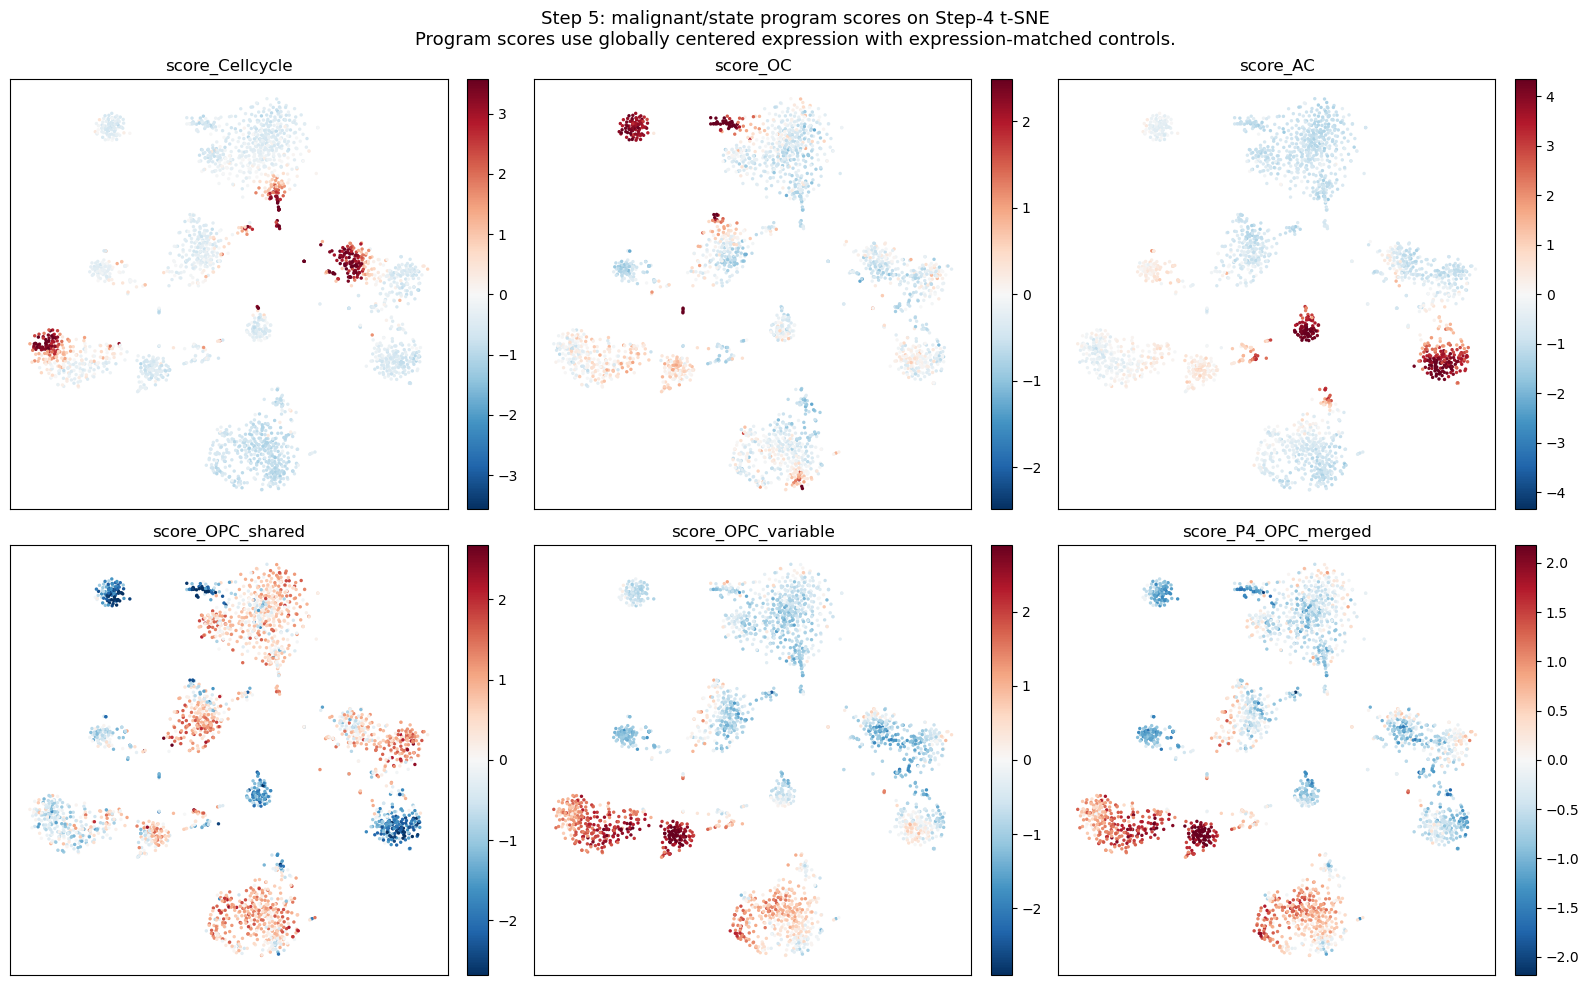

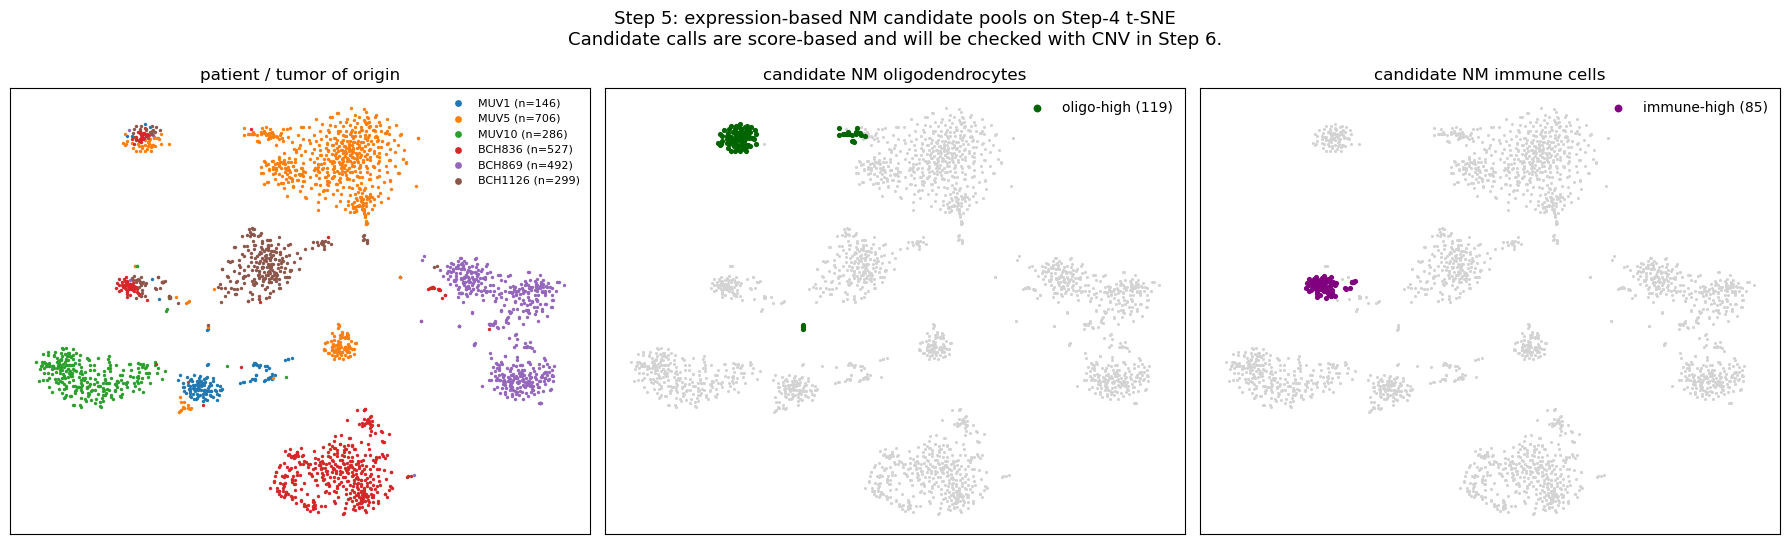

cell-cycle-high cells (score > 1.0): 317

by tumor:
BCH869     113
MUV10      109
MUV5        56
BCH1126     22
BCH836      12
MUV1         5
Name: patient, dtype: int64

t-SNE location of cell-cycle-high cells:
  X: mean=-2.1 (full range [-37.7, 34.4])
  Y: mean=1.5 (full range [-40.4, 37.3])


In [29]:
# ---------------------------------------------------------------
# Step 5 visualization — program scores and NM candidates on t-SNE
# ---------------------------------------------------------------

import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

os.makedirs("../figures/step5", exist_ok=True)

# Step 4 post-removal t-SNE coordinates
tsne = adata.obsm["X_tsne_corr_postremoval"]


# ---------------------------------------------------------------
# Panel 1: six malignant/state program scores on the t-SNE
# ---------------------------------------------------------------

programs_to_plot = [
    "Cellcycle",
    "OC",
    "AC",
    "OPC_shared",
    "OPC_variable",
    "P4_OPC_merged",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, prog in zip(axes.flat, programs_to_plot):
    s = adata.obs[f"score_{prog}"].to_numpy()

    # Symmetric color scale around 0 for centered/global-relative scores
    vmax = np.percentile(np.abs(s), 98)

    sca = ax.scatter(
        tsne[:, 0],
        tsne[:, 1],
        c=s,
        cmap="RdBu_r",
        vmin=-vmax,
        vmax=vmax,
        s=6,
        linewidths=0,
    )

    ax.set_title(f"score_{prog}", fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])

    plt.colorbar(sca, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(
    "Step 5: malignant/state program scores on Step-4 t-SNE\n"
    "Program scores use globally centered expression with expression-matched controls.",
    fontsize=13,
)

plt.tight_layout()

plt.savefig(
    "../figures/step5/program_scores_tsne_global.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


# ---------------------------------------------------------------
# Panel 2: patient/tumor of origin + NM candidates
# ---------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# (a) patient/tumor of origin
for pt in patient_order:
    m = (adata.obs["patient"] == pt).to_numpy()

    axes[0].scatter(
        tsne[m, 0],
        tsne[m, 1],
        s=6,
        label=f"{pt} (n={m.sum()})",
        linewidths=0,
        color=mcolors.to_hex(pt_cmap(pt_to_idx[pt])),
    )

axes[0].legend(markerscale=2, fontsize=8, frameon=False)
axes[0].set_title("patient / tumor of origin")
axes[0].set_xticks([])
axes[0].set_yticks([])


# (b) oligo-high candidates
oh = (adata.obs["score_NM_oligodendrocyte"] > 2.0).to_numpy()

axes[1].scatter(
    tsne[~oh, 0],
    tsne[~oh, 1],
    s=5,
    c="lightgray",
    linewidths=0,
)

axes[1].scatter(
    tsne[oh, 0],
    tsne[oh, 1],
    s=14,
    c="darkgreen",
    linewidths=0,
    label=f"oligo-high ({oh.sum()})",
)

axes[1].legend(markerscale=1.5, frameon=False)
axes[1].set_title("candidate NM oligodendrocytes")
axes[1].set_xticks([])
axes[1].set_yticks([])


# (c) immune-high candidates
ih = (adata.obs["score_NM_immune"] > 2.0).to_numpy()

axes[2].scatter(
    tsne[~ih, 0],
    tsne[~ih, 1],
    s=5,
    c="lightgray",
    linewidths=0,
)

axes[2].scatter(
    tsne[ih, 0],
    tsne[ih, 1],
    s=14,
    c="purple",
    linewidths=0,
    label=f"immune-high ({ih.sum()})",
)

axes[2].legend(markerscale=1.5, frameon=False)
axes[2].set_title("candidate NM immune cells")
axes[2].set_xticks([])
axes[2].set_yticks([])


fig.suptitle(
    "Step 5: expression-based NM candidate pools on Step-4 t-SNE\n"
    "Candidate calls are score-based and will be checked with CNV in Step 6.",
    fontsize=13,
)

plt.tight_layout()

plt.savefig(
    "../figures/step5/tumor_and_nm_tsne_global.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


# ---------------------------------------------------------------
# Quantitative check: where are cell-cycle-high cells?
# ---------------------------------------------------------------

cc_hi = (adata.obs["score_Cellcycle"] > 1.0).to_numpy()

print(f"cell-cycle-high cells (score > 1.0): {cc_hi.sum()}")

print("\nby tumor:")
print(adata.obs.loc[cc_hi, "patient"].value_counts())

print("\nt-SNE location of cell-cycle-high cells:")
print(
    f"  X: mean={tsne[cc_hi, 0].mean():.1f} "
    f"(full range [{tsne[:, 0].min():.1f}, {tsne[:, 0].max():.1f}])"
)

print(
    f"  Y: mean={tsne[cc_hi, 1].mean():.1f} "
    f"(full range [{tsne[:, 1].min():.1f}, {tsne[:, 1].max():.1f}])"
)

rows per block: {'P1_Cellcycle': 30, 'P2_AC': 30, 'P3_OC': 30, 'P4_OPC_shared': 19} | total rows: 109
clustered 2456 cells on 6 program scores


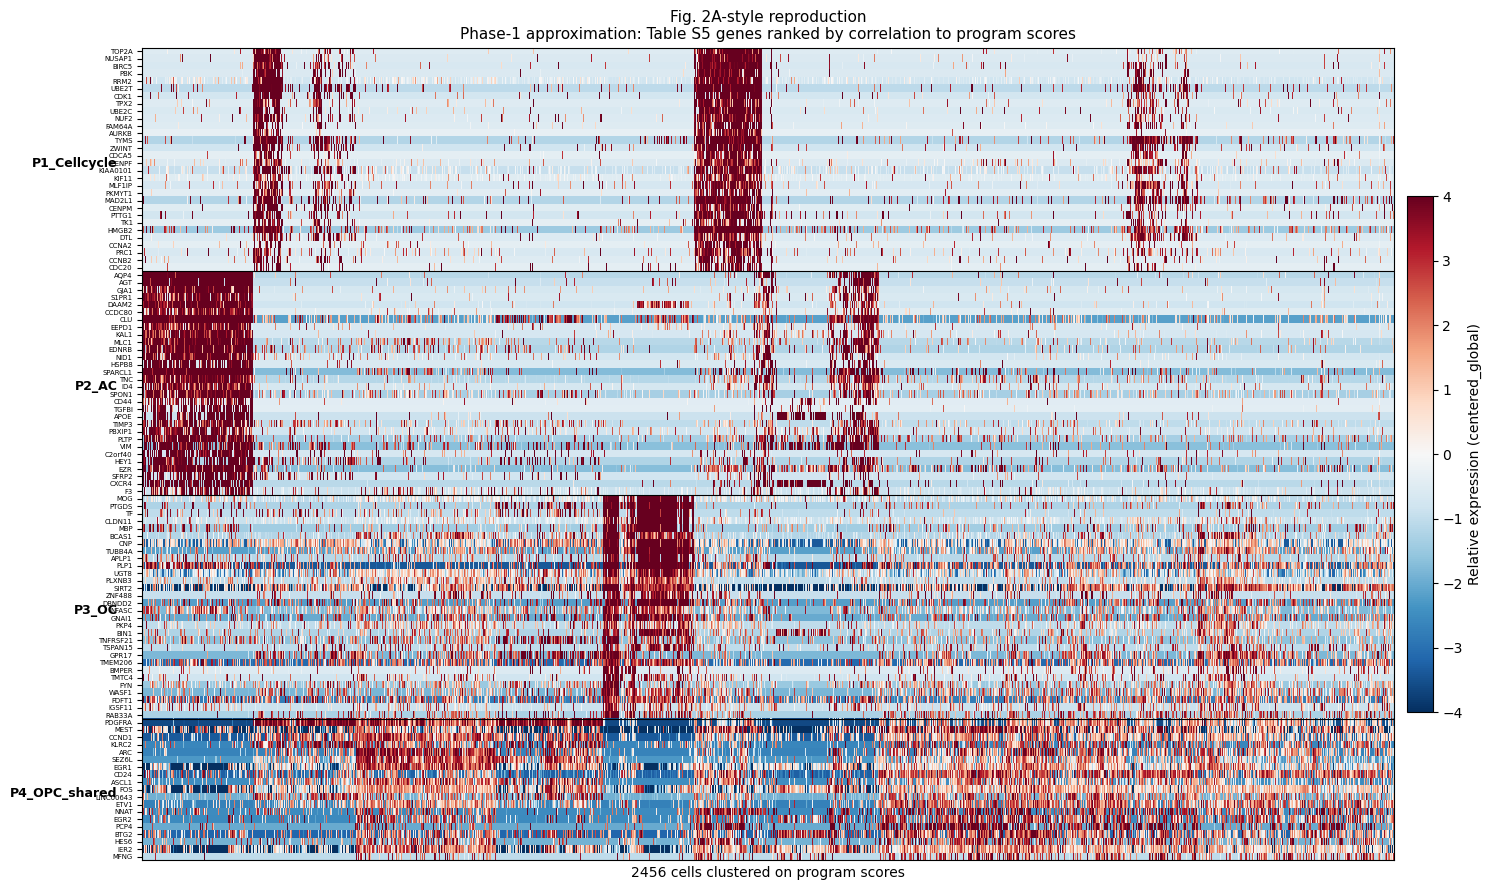

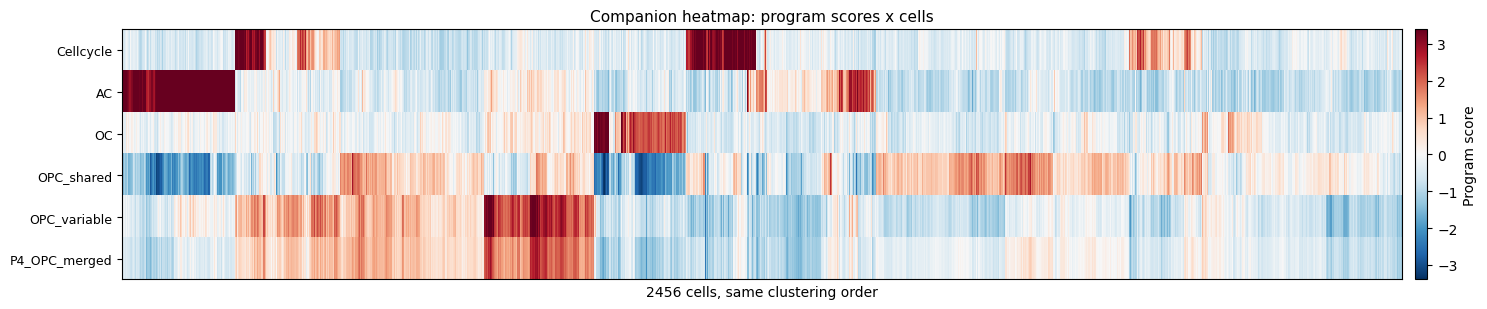

In [30]:
import scanpy as sc, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
import os

os.makedirs("../figures/step5", exist_ok=True)

# ---------------------------------------------------------------
# 1. Pick heatmap row genes: top 30 per program by correlation to
#    that program's score.
#
# Phase-1 approximation:
#   We use Table S5 signature genes and rank them by correlation
#   to the corresponding program score.
#
# Phase-2 plan:
#   Re-derive top genes from NNMF meta-programs, closer to Filbin.
# ---------------------------------------------------------------

Er = adata.layers["centered_global"]
Er = Er if isinstance(Er, np.ndarray) else Er.toarray()

gidx = {g: i for i, g in enumerate(adata.var_names)}

def top_genes_by_corr(sig_genes, score_vec, n):
    cand = [g for g in sig_genes if g in gidx]

    cors = {}
    for g in cand:
        r = np.corrcoef(Er[:, gidx[g]], score_vec)[0, 1]
        cors[g] = r

    return [
        g for g, _ in sorted(
            cors.items(),
            key=lambda kv: kv[1],
            reverse=True,
        )[:n]
    ]

row_blocks = {
    "P1_Cellcycle":  top_genes_by_corr(programs["Cellcycle"], adata.obs["score_Cellcycle"].values, 30),
    "P2_AC":         top_genes_by_corr(programs["AC"],        adata.obs["score_AC"].values,        30),
    "P3_OC":         top_genes_by_corr(programs["OC"],        adata.obs["score_OC"].values,        30),
    "P4_OPC_shared": [g for g in programs["OPC_shared"] if g in gidx],  # 19 shared OPC genes
}

row_genes = sum(row_blocks.values(), [])
row_labels_block = sum([[k] * len(v) for k, v in row_blocks.items()], [])

print("rows per block:", {k: len(v) for k, v in row_blocks.items()}, "| total rows:", len(row_genes))


# ---------------------------------------------------------------
# 2. Cluster cells on the 6 program scores
# ---------------------------------------------------------------

score_cols = [
    "score_Cellcycle",
    "score_AC",
    "score_OC",
    "score_OPC_shared",
    "score_OPC_variable",
    "score_P4_OPC_merged",
]

S = adata.obs[score_cols].to_numpy()

Z = linkage(S, method="ward")
order = leaves_list(Z)

print(f"clustered {len(order)} cells on {len(score_cols)} program scores")


# ---------------------------------------------------------------
# 3. FIGURE 1 — Fig. 2A-style heatmap: genes x cells, Er
# ---------------------------------------------------------------

M = Er[np.ix_(order, [gidx[g] for g in row_genes])].T  # genes x cells

fig, ax = plt.subplots(figsize=(15, 9))

im = ax.imshow(
    M,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-4,
    vmax=4,
    interpolation="nearest",
)

ax.set_yticks(range(len(row_genes)))
ax.set_yticklabels(row_genes, fontsize=5)
ax.set_xticks([])
ax.set_xlabel(f"{len(order)} cells clustered on program scores")

# Row-block separators
boundary = np.cumsum([len(v) for v in row_blocks.values()])[:-1]

for b in boundary:
    ax.axhline(b - 0.5, color="k", lw=0.8)

starts = np.cumsum([0] + [len(v) for v in row_blocks.values()])[:-1]

for k, ypos in zip(row_blocks, starts):
    ax.text(
        -len(order) * 0.02,
        ypos + len(row_blocks[k]) / 2,
        k,
        ha="right",
        va="center",
        fontsize=9,
        fontweight="bold",
    )

plt.colorbar(
    im,
    ax=ax,
    fraction=0.02,
    pad=0.01,
    label="Relative expression (centered_global)",
)

ax.set_title(
    "Fig. 2A-style reproduction\n"
    "Phase-1 approximation: Table S5 genes ranked by correlation to program scores",
    fontsize=11,
)

plt.tight_layout()

plt.savefig(
    "../figures/step5/fig2A_style_phase1_global.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


# ---------------------------------------------------------------
# 4. FIGURE 2 — companion score heatmap: 6 programs x cells
# ---------------------------------------------------------------

SC = adata.obs[score_cols].to_numpy()[order].T

fig, ax = plt.subplots(figsize=(15, 3.2))

vmax = np.percentile(np.abs(SC), 98)

im = ax.imshow(
    SC,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
    interpolation="nearest",
)

ax.set_yticks(range(len(score_cols)))
ax.set_yticklabels(
    [c.replace("score_", "") for c in score_cols],
    fontsize=9,
)

ax.set_xticks([])
ax.set_xlabel(f"{len(order)} cells, same clustering order")

plt.colorbar(
    im,
    ax=ax,
    fraction=0.02,
    pad=0.01,
    label="Program score",
)

ax.set_title(
    "Companion heatmap: program scores x cells",
    fontsize=11,
)

plt.tight_layout()

plt.savefig(
    "../figures/step5/fig2A_score_companion_global.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

>This Phase-1 Fig. 2A-style heatmap uses Table S5 signature genes rather than NNMF-derived meta-program gene sets. Cells were clustered by their six program scores, and gene rows were selected by correlation between centered-global expression and the corresponding program score. The companion heatmap confirms that the cell ordering captures distinct program-enriched regions, including cell-cycle, AC-like, OC-like, and OPC-like patterns. Because the original Filbin Fig. 2A was based on NNMF/meta-program-derived genes, this plot should be interpreted as a score-based approximation rather than a full reproduction.

In [31]:
adata.var

,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,mt,ribo,hb,Ea,mean_E_global,mean_E_MUV1,mean_E_MUV5,mean_E_MUV10,mean_E_BCH836,mean_E_BCH869,mean_E_BCH1126,mean_E_global_post_artifact_removal
Gene,,,,,,,,,,,,,,,,
A2M,966,171.771412,76.195170,697048.39,False,False,False,6.444528,0.423023,0.525879,0.180120,0.172948,1.020637,0.071075,0.712974,0.423271
AAAS,1701,69.805473,58.082799,283270.61,False,False,False,6.230818,1.504036,1.228943,1.682671,1.358791,1.614783,1.489744,1.182624,1.502954
AACS,1039,17.232048,74.396254,69927.65,False,False,False,4.145992,0.559294,0.416442,0.522972,0.390963,0.827035,0.531099,0.450553,0.559749
AADAT,919,20.766848,77.353376,84271.87,False,False,False,4.736881,0.665913,0.578937,0.575417,0.691771,0.795687,0.785746,0.472015,0.664156
AAGAB,1497,38.298682,63.109906,155416.05,False,False,False,5.028065,0.816171,0.341341,0.736281,0.501583,0.941588,1.061732,0.912992,0.815053
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZWINT,797,74.239662,80.359783,301264.55,False,False,False,6.096422,0.800185,0.227817,0.692281,2.143746,0.197175,1.180149,0.487637,0.798406
ZXDC,3537,20.600136,12.838837,83595.35,False,False,False,4.578611,1.055747,1.031243,0.527951,0.635029,1.684520,1.501098,0.878842,1.054785
ZYG11B,3364,17.410412,17.102021,70651.45,False,False,False,4.300367,0.906467,1.003750,0.659226,0.734138,1.343509,1.051674,0.600001,0.905719


In [32]:
# ---------------------------------------------------------------
# Freeze Step 5 output
# ---------------------------------------------------------------

import scanpy as sc
import numpy as np
import os

OUT = "../data/processed/Filbin_step5.h5ad"

adata.write_h5ad(OUT, compression="gzip")

size_mb = os.path.getsize(OUT) / 1024**2
print(f"wrote {OUT}  ({size_mb:.1f} MB)")


# ---------------------------------------------------------------
# Round-trip verification on the real file
# ---------------------------------------------------------------

chk = sc.read_h5ad(OUT)

# Shape unchanged from Step 4 final object
assert chk.shape == (2456, 8494), f"shape drift: {chk.shape}"

# 8 score columns present
score_cols = [
    "score_Cellcycle",
    "score_OC",
    "score_AC",
    "score_OPC_shared",
    "score_OPC_variable",
    "score_P4_OPC_merged",
    "score_NM_oligodendrocyte",
    "score_NM_immune",
]

missing = [c for c in score_cols if c not in chk.obs.columns]
assert not missing, f"missing score cols: {missing}"

# Step 4 anchors carried forward
assert "centered_global" in chk.layers
assert "centered_within_tumor" in chk.layers
assert "tpm" in chk.layers

assert "correlation_centered_global" in chk.obsp
assert "distance_centered_global" in chk.obsp

assert "X_tsne_corr_postremoval" in chk.obsm
assert "step4" in chk.uns

# Step 5 metadata intact
assert "step5_nm" in chk.uns

nm = chk.uns["step5_nm"]

assert len(nm["reference_oligo_cells"]) == 138
assert len(nm["oligo_high_cells"]) == 119
assert len(nm["immune_high_cells"]) == 85

assert set(nm["reference_scores"].keys()) == {
    "AC",
    "Cellcycle",
    "NM_immune",
    "NM_oligodendrocyte",
    "OC",
    "OPC_shared",
}

assert "group_summary_absolute_E" in nm

# Score values survived
assert abs(chk.obs["score_NM_oligodendrocyte"].mean() - adata.obs["score_NM_oligodendrocyte"].mean()) < 1e-6
assert abs(chk.obs["score_NM_immune"].mean() - adata.obs["score_NM_immune"].mean()) < 1e-6

# Candidate pools are still reflected in obs scores
oligo_hi = chk.obs["score_NM_oligodendrocyte"] > 2.0
immune_hi = chk.obs["score_NM_immune"] > 2.0

assert oligo_hi.sum() == 119, f"oligo-high count drift: {oligo_hi.sum()}"
assert immune_hi.sum() == 85, f"immune-high count drift: {immune_hi.sum()}"

print("Filbin_step5.h5ad round-trips cleanly:")
print(f"  shape:              {chk.shape}")
print(f"  score cols:         {len(score_cols)}")
print(f"  Step 4 anchors:     centered_global, correlation_centered_global, X_tsne_corr_postremoval")
print(f"  Step 5 metadata:    uns['step5_nm']")
print(f"  reference oligos:   {len(nm['reference_oligo_cells'])}")
print(f"  oligo-high cells:   {len(nm['oligo_high_cells'])}")
print(f"  immune-high cells:  {len(nm['immune_high_cells'])}")

wrote ../data/processed/Filbin_step5.h5ad  (208.2 MB)
Filbin_step5.h5ad round-trips cleanly:
  shape:              (2456, 8494)
  score cols:         8
  Step 4 anchors:     centered_global, correlation_centered_global, X_tsne_corr_postremoval
  Step 5 metadata:    uns['step5_nm']
  reference oligos:   138
  oligo-high cells:   119
  immune-high cells:  85
